# Imports

In [36]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets

import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Preprocessing


## Combining Datasets
The data being used consists of 5 separate datasets all containing 2000 each. Our first step was to combine them into one large one. We also dropped the category column at this point to prevent the model from clustering with it.

In [2]:
bussiness_df = pd.read_csv("data/business_data.csv")
education_df = pd.read_csv("data/education_data.csv")
entertainment_df = pd.read_csv("data/entertainment_data.csv")
sports_df = pd.read_csv("data/sports_data.csv")
tech_df = pd.read_csv("data/technology_data.csv")

In [3]:
df = pd.concat([bussiness_df,education_df,entertainment_df,sports_df,tech_df],axis=0)
df.head()

,headlines,description,content,url,category
0,Nirmala Sitharaman to equal Morarji Desai’s re...,With the presentation of the interim budget on...,"Sitharaman, the first full-time woman finance ...",https://indianexpress.com/article/business/bud...,business
1,"‘Will densify network, want to be at least no....","'In terms of market share, we aim to double it...",The merger of Tata group’s budget airlines Air...,https://indianexpress.com/article/business/avi...,business
2,Air India group to induct an aircraft every si...,Air India currently has 117 operational aircra...,The Air India group plans to induct one aircra...,https://indianexpress.com/article/business/avi...,business
3,Red Sea woes: Exporters seek increased credit ...,Rising attacks forced shippers to consider the...,Indian exporters have asked the central govern...,https://indianexpress.com/article/business/red...,business
4,Air India group to induct a plane every 6 days...,"Apart from fleet expansion, 2024 will also see...",The Air India group plans to induct one aircra...,https://indianexpress.com/article/business/avi...,business


In [4]:
df.drop(["url","category"], axis=1,inplace=True)
df.head()

,headlines,description,content
0,Nirmala Sitharaman to equal Morarji Desai’s re...,With the presentation of the interim budget on...,"Sitharaman, the first full-time woman finance ..."
1,"‘Will densify network, want to be at least no....","'In terms of market share, we aim to double it...",The merger of Tata group’s budget airlines Air...
2,Air India group to induct an aircraft every si...,Air India currently has 117 operational aircra...,The Air India group plans to induct one aircra...
3,Red Sea woes: Exporters seek increased credit ...,Rising attacks forced shippers to consider the...,Indian exporters have asked the central govern...
4,Air India group to induct a plane every 6 days...,"Apart from fleet expansion, 2024 will also see...",The Air India group plans to induct one aircra...


In [5]:
print(df.shape,"\n")


(10000, 3) 



In [6]:
df.isna().sum()

headlines      0
description    0
content        0
dtype: int64

## Text Cleaning

* Lowercasing — obvious, but easy to forget
* Removing punctuation, special characters, HTML/URLs depending on your data source
* Stopword removal 
* Lemmatization

In [ ]:
nlp = spacy.load("en_core_web_sm")

df["Text"]  = df["headlines"] + " " + df["description"] + " " + df["content"]

def cleanColumn(df, col):
    df[col] = df[col].str.lower()
    df[col] = df[col].apply(lambda x: nlp(x))
    
    #Lemmatization and removing the puctuation
    df[col] = df[col].apply(lambda x: [token.lemma_ for token in x if not token.is_punct and not token.is_stop])

    #Rejoin the lemmas
    df[col] = df[col].apply(lambda x: " ".join(x))

In [8]:
df2 = df.copy()
cleanColumn(df2, "Text")

In [9]:
df2["Text"]

0       nirmala sitharaman equal morarji desai record ...
1       densify network want 2 city pair air india exp...
2       air india group induct aircraft day year air i...
3       red sea woe exporter seek increase credit frei...
4       air india group induct plane 6 day 2024 kick l...
                              ...                        
1995    vivaldi privacy customisability focus browser ...
1996    meta quest 3 ray ban smart glass announce conn...
1997    samsung galaxy s24 rumour launch january 18 sa...
1998    continuously iterate building prototype testin...
1999    chatgpt user browse internet openai say chatgp...
Name: Text, Length: 10000, dtype: str

In [10]:

df2.to_csv("data/cleaned_data.csv", index=False)


In [ ]:
#Instead of having to reclean the data after a restart just load the cleaned data in
df2 = pd.read_csv("data/cleaned_data.csv")

## Feature Transformation 
With the text data cleaned we then used TF-IDF to convert the text into a numerical representation and then applied a Truncated SVD transformation to reduce the dimensions of the TF-IDF matrix 


In [11]:
TF_IDF = TfidfVectorizer(max_df=0.95) # Cappping features to remove extreme outliers
text = df2["Text"]
vectorized_text = TF_IDF.fit_transform(text)
vectorized_text

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 940669 stored elements and shape (10000, 43580)>

### Applying Truncated SVD


In [12]:
svd = TruncatedSVD(n_components=500, random_state=6)
svd.fit_transform(vectorized_text)
#Using the cumulative sum we can find how much variance is explained by each number of components
cumulative_variance = np.cumsum(svd.explained_variance_ratio_)

In [13]:
#Since the number of components start at 1 the range of components is adjusted 
comp_df = pd.DataFrame(data= {"Number of components": np.arange(1,501),
                              "Total Variance": cumulative_variance})

In [14]:
components = 300
svd_o = TruncatedSVD(n_components=components)
reduced_matrix = svd_o.fit_transform(vectorized_text)
norm = Normalizer(copy=False)
reduced_matrix = norm.fit_transform(reduced_matrix)
print(f"Explained variance: {svd_o.explained_variance_ratio_.sum()}")

 

Explained variance: 0.3364720353490931


# Model Training

## KMeans

In [ ]:
#The optimal k value was found using plotting 
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=6)
    kmeans.fit(reduced_matrix)
    wcss.append(kmeans.inertia_)

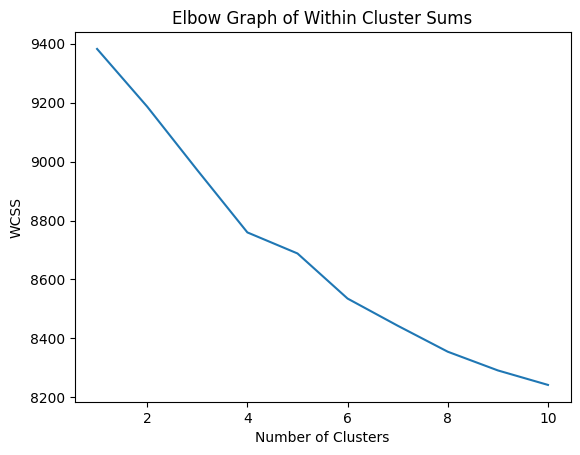

In [ ]:
plt.plot(range(1,11),wcss)
plt.title("Elbow Graph of Within Cluster Sums")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [17]:
kmeans = KMeans(n_clusters=5, init="k-means++", random_state=6)
labels = kmeans.fit_predict(reduced_matrix)
sil_score = silhouette_score(reduced_matrix,labels)
dbs = davies_bouldin_score(reduced_matrix,labels)

In [18]:
print(f"Silhouette Score: {sil_score}")
print(f"Davies-Bouldin Score: {dbs}")

Silhouette Score: 0.03524827182426941
Davies-Bouldin Score: 4.629671208538673


## DBscan

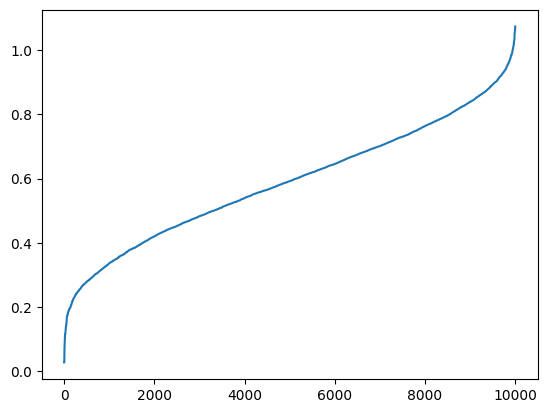

In [ ]:
#The optimal eps value was found using a similar method to k means' k
nn = NearestNeighbors(n_neighbors = 5)
nn_fit = nn.fit(reduced_matrix)
d,indices  = nn_fit.kneighbors(reduced_matrix)
d = np.sort(d, axis=0)
d = d[:,1]
plt.plot(d)

In [ ]:
db = DBSCAN(eps=0.9,min_samples=5)
db_labels = db.fit_predict(reduced_matrix)
clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)

In [31]:
# We can actually filter the noise out before evaluating 
db_sil = silhouette_score(reduced_matrix[db_labels != -1],db_labels[db_labels != -1])
db_dbs = davies_bouldin_score(reduced_matrix[db_labels != -1],db_labels[db_labels != -1])

noise = list(db_labels).count(-1)
print(f"Noise identified: {noise}")
print(f"Clusters found: {clusters}")
print(f"Silhouette score for dbscan: {db_sil}")
print(f"Davis Boulldin score for dbscan: {db_dbs}")

Noise identified: 619
Clusters found: 6
Silhouette score for dbscan: -0.03174953685301771
Davis Boulldin score for dbscan: 1.7734761082962176


## Agglomerative Clustering

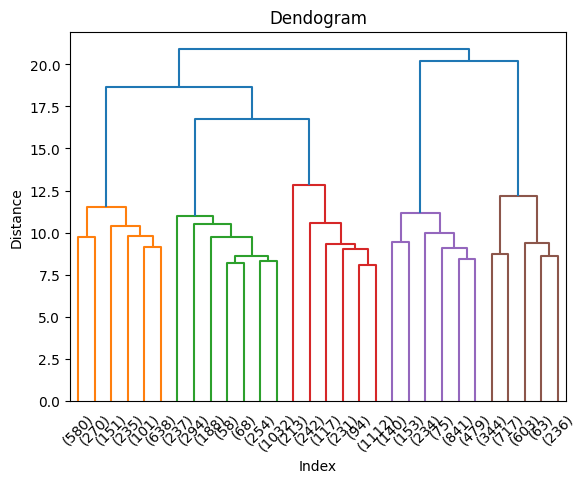

In [ ]:
#We used the dendogram to find an appropriate cluster number
link = sch. linkage(reduced_matrix, method="ward")
plt.figure(figsize=(12,5))
sch.dendrogram(link, truncate_mode="lastp", p=30)
plt.title("Dendogram")
plt.xlabel("Index")
plt.ylabel("Distance")
plt.show()


In [38]:
agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
agg_labels = agg.fit_predict(reduced_matrix)
agg_sil = silhouette_score(reduced_matrix, agg_labels)
agg_dbs = davies_bouldin_score(reduced_matrix, agg_labels)
print(f"Silhouette Score: {agg_sil}")
print(f"Davies-Bouldin Score: {agg_dbs}")

Silhouette Score: 0.04426587235132984
Davies-Bouldin Score: 4.8677307493732656
